# Lab 1 Environment Setup
Before starting this lab, we need to set up our Python environment. Follow these steps in your terminal:

First, we'll create a new conda environment named 'lab_1' with Python 3.9:

```conda create --name lab_1 python=3.9 ```


After the environment is created, activate it:

```conda activate lab_1 ```


Install the IPython kernel to enable the environment in Jupyter: 

```conda install ipykernel ```

Note: Make sure you have Anaconda or Miniconda installed on your system before running these commands. After completing these steps, you'll have a clean Python 3.9 environment ready for the lab exercises.

To verify your setup:

- Your terminal prompt should show (lab_1) indicating the environment is active

- Running python --version should show Python 3.9.x

- The environment should be available as a kernel option in Jupyter

Now you're ready to proceed with the lab exercises!

In [25]:
!pip install --quiet torch torchvision matplotlib scikit-learn

In [4]:
import torch
import torch.nn as nn

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('GPU State:', device)

GPU State: cpu


In [5]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, std: float = 0.1):
        """
        Initialize a linear layer with random weights.

        Weights and biases are registered as parameters, allowing for 
        gradient computation and update during backpropagation.
        """
        super(Linear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        weight = torch.randn(in_features, out_features, requires_grad=True) * std
        bias = torch.zeros(out_features, requires_grad=True)
        
        self.weight = nn.Parameter(weight)
        self.bias = nn.Parameter(bias)
        self.to(device=device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform linear transformation by multiplying the input tensor
        with the weight matrix, and adding the bias.
        """
        return x @ self.weight + self.bias

    def __repr__(self) -> str:
        return f'in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None}'

In [6]:
class ReLU(nn.Module):
    """
    Rectified Linear Unit (ReLU) activation function.
    """

    @staticmethod
    def forward(x: torch.Tensor) -> torch.Tensor:
        return torch.clip(x, 0.)

In [7]:
class Dropout(nn.Module):
    """
    Applies the dropout regularization technique to the input tensor.

    During training, it randomly sets a fraction of input units to 0 with probability `p`,
    scaling the remaining values by `1 / (1 - p)` to maintain the same expected output sum.
    During evaluation, no dropout is applied.
    """

    def __init__(self, p=0.2):
        super(Dropout, self).__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            mask = (torch.rand(x.shape) > self.p).float().to(x) / (1 - self.p)
            return x * mask
        return x

In [11]:
class Flatten(nn.Module):
    """
    Reshape the input tensor by flattening all dimensions except the first dimension.
    """

    @staticmethod
    def forward(x: torch.Tensor) -> torch.Tensor:
        """
        x.view(x.size(0), -1) reshapes the x tensor to (x.size(0), N)
        where N is the product of the remaining dimensions.
        E.g. (batch_size, 28, 28) -> (batch_size, 784)
        """
        return x.view(x.size(0), -1)

In [8]:
class Sequential(nn.Module):
    """
    Sequential container for stacking multiple modules,
    passing the output of one module as input to the next.
    """

    def __init__(self, *layers):
        super(Sequential, self).__init__()
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x

    def __repr__(self) -> str:
        layer_str = '\n'.join([f' ({i}): {layer}' for i, layer in enumerate(self.layers)])
        return f'{self.__class__.__name__}(\n{layer_str}\n)'

In [12]:
class Classifier(nn.Module):
    """
    Classifier model consisting of a sequence of linear layers and ReLU activations,
    followed by a final linear layer that outputs logits (unnormalized scores)
    for each of the 10 garment classes.

    It encapsulates also a method to convert logits into a label/probability dict.
    """

    def __init__(self):
        """
        The output logits of the last layer can be passed directly to
        a loss function like CrossEntropyLoss, which will apply the 
        softmax function internally to calculate a probability distribution.
        """
        super(Classifier, self).__init__()
        self.labels = ['T-shirt/Top', 'Trouser/Jeans', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle-Boot']
        
        self.main = Sequential(
            Flatten(),
            Linear(in_features=784, out_features=256),
            ReLU(),
            Dropout(0.2),
            Linear(in_features=256, out_features=64),
            ReLU(),
            Dropout(0.2),
            Linear(in_features=64, out_features=10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.main(x)
    
    def predictions(self, x):
        with torch.no_grad():
            logits = self.forward(x)
            probs = torch.nn.functional.softmax(logits, dim=1)
            predictions = dict(zip(self.labels, probs.cpu().detach().numpy().flatten()))    
        return predictions

In [13]:
model = Classifier().to(device)
model

Classifier(
  (main): Sequential(
   (0): Flatten()
   (1): in_features=784, out_features=256, bias=True
   (2): ReLU()
   (3): Dropout()
   (4): in_features=256, out_features=64, bias=True
   (5): ReLU()
   (6): Dropout()
   (7): in_features=64, out_features=10, bias=True
  )
)

In [14]:
list(model.parameters())[0]

Parameter containing:
tensor([[-0.0549,  0.2080, -0.0181,  ..., -0.2259, -0.1998, -0.0784],
        [ 0.0458,  0.0787,  0.0164,  ...,  0.0263, -0.2526, -0.0402],
        [ 0.1015, -0.0273, -0.1615,  ..., -0.0043, -0.0053,  0.2347],
        ...,
        [-0.0838,  0.0694, -0.0855,  ..., -0.0755, -0.0118, -0.0502],
        [ 0.0385, -0.1764,  0.0175,  ..., -0.1933,  0.0384,  0.0492],
        [ 0.0818,  0.0937, -0.1347,  ..., -0.0156, -0.1005, -0.1362]],
       requires_grad=True)

In [15]:
class Optimizer:
    """
    Update model parameters during training.
    
    It performs a simple gradient descent step by updating the parameters
    based on their gradients and the specified learning rate (lr).
    """

    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr

    def step(self):
        for p in self.params:
            p.data -= p.grad.data * self.lr

    def zero_grad(self):
        """
        Reset the gradients of all parameters to zero.
        Since PyTorch accumulates gradients, this method ensures that
        the gradients from previous optimization steps do not interfere
        with the current step.
        """
        for p in self.params:
            p.grad = None

In [16]:
from dataclasses import dataclass

@dataclass
class LearnerConfig:
    """
    Configuration class for the Learner.

    This class holds the hyperparameters and settings for training the model.
    """

    model: nn.Module
    criterion: nn.Module
    epochs: int
    batch_size: int
    lr: float
    device: str

# Example configuration
config = LearnerConfig(
    model=model,
    criterion=nn.CrossEntropyLoss(),
    epochs=25,
    batch_size=32,
    lr=0.005,
    device=device,
)

In [17]:
from torchvision.transforms import ToTensor
from torchvision import datasets
from torch.utils.data import DataLoader

train_data = datasets.FashionMNIST(root = 'data', train = True, transform = ToTensor(), download = True)
test_data = datasets.FashionMNIST(root = 'data', train = False, transform = ToTensor())

loaders = {'train' : DataLoader(train_data, batch_size=config.batch_size, shuffle=True, num_workers=2),
           'test'  : DataLoader(test_data, batch_size=config.batch_size, shuffle=False, num_workers=2)}

100.0%
100.0%
100.0%
100.0%


In [18]:
train_data.data.size(), test_data.data.size()

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

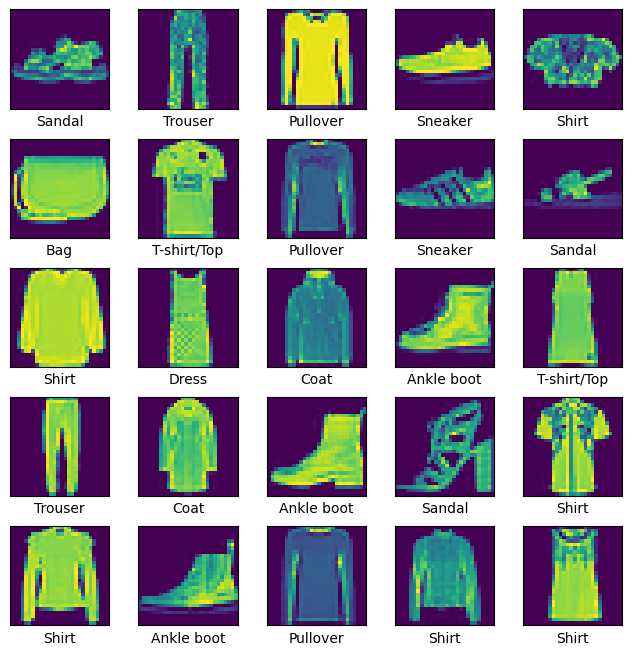

In [21]:
import matplotlib.pyplot as plt 

label_names = ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
figure = plt.figure(figsize=(8, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img.squeeze())
    plt.xlabel(label_names[label])
plt.subplots_adjust(hspace=0.3)
plt.show()

In [22]:
img.size()

torch.Size([1, 28, 28])

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

class Learner:
    """
    Learner class for training and evaluating a model.

    This class encapsulates the training and validation loops, as well as
    utility methods for prediction, exporting the model, and calculating
    accuracy.
    """

    def __init__(self, config, loaders):
        """
        Initialize the Learner.

        Args:
            config (LearnerConfig): Configuration for the Learner.
            loaders (dict): Dictionary of data loaders for training and testing.
        """
        self.model = config.model
        self.loaders = loaders
        self.optimizer = Optimizer(self.model.parameters(), config.lr)
        self.criterion = config.criterion
        self.epochs = config.epochs
        self.device = config.device
        self.labels = ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle-Boot']
        self.model.to(self.device)

    def train_epoch(self, epoch):
        """
        Train the model for one epoch.
        """
        epoch_loss = 0.0
        for x, y in self.loaders["train"]:
            x, y = x.to(self.device), y.to(self.device)
            batch_size = x.size(0)

            # Zero out the gradients - otherwise, they will accumulate.
            self.optimizer.zero_grad()
   
            # Forward pass, loss calculation, and backpropagation
            output = self.model(x)
            loss = self.criterion(output, y)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item() * batch_size

        train_loss = epoch_loss / len(self.loaders['train'].dataset)
        return train_loss
    
    def valid_loss(self):
        """
        Calculate the validation loss.
        """
        self.model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in self.loaders["test"]:
                x, y = x.to(self.device), y.to(self.device)
                output = self.model(x)
                val_loss += self.criterion(output, y).item() * y.size(0)
        val_loss /= len(self.loaders["test"].dataset)
        return val_loss

    def batch_accuracy(self, x, y):
        """
        Calculate the accuracy for a batch of inputs (x) and targets (y).
        """        
        _, preds = torch.max(x.data, 1)
        return (preds == y).sum().item() / x.size(0)

    def validate_epoch(self):
        """
        Evaluate the model on the test dataset after an epoch.
        """        
        accs = [self.batch_accuracy(self.model(x.to(self.device)), y.to(self.device))
                for x, y in self.loaders["test"]]
        return sum(accs) / len(accs)
            
    def fit(self):
        """
        Train the model for the specified number of epochs.
        """
        print('epoch\ttrain_loss\tval_loss\ttest_accuracy')
        for epoch in range(self.epochs):
            train_loss = self.train_epoch(epoch)
            valid_loss = self.valid_loss()
            batch_accuracy = self.validate_epoch()
            print(f'{epoch+1}\t{train_loss:.6f}\t{valid_loss:.6f}\t{batch_accuracy:.6f}')

        metrics = self.evaluate()
        return metrics
    
    def export(self, path):
        torch.save(self.model, path)
                            
    def evaluate(self):
        self.model.eval()
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for x, y in self.loaders["test"]:
                x, y = x.to(self.device), y.to(self.device)
                outputs = self.model(x)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.cpu().numpy())

        class_precision = precision_score(all_targets, all_preds, average=None)
        class_recall = recall_score(all_targets, all_preds, average=None)
        class_f1 = f1_score(all_targets, all_preds, average=None)

        metrics = {label: {"precision": prec, "recall": rec, "f1": f1}
                   for label, prec, rec, f1 in zip(self.labels, class_precision, class_recall, class_f1)}

        return metrics

In [27]:
learner = Learner(config, loaders)

In [28]:
metrics = learner.fit()

epoch	train_loss	val_loss	test_accuracy
1	1.053508	0.673014	0.760883
2	0.568555	0.552406	0.805611
3	0.497724	0.505763	0.825080
4	0.465305	0.486048	0.831470
5	0.442820	0.470589	0.834365
6	0.426154	0.447191	0.841054
7	0.412441	0.448525	0.840455
8	0.400858	0.428449	0.846346
9	0.390487	0.433346	0.843051
10	0.381667	0.428682	0.846446
11	0.373477	0.413331	0.850639
12	0.365969	0.405793	0.856629
13	0.359560	0.406602	0.855032
14	0.353996	0.397568	0.858227
15	0.347850	0.403877	0.856230
16	0.342418	0.388616	0.863518
17	0.337306	0.384700	0.862121
18	0.332932	0.388301	0.861522
19	0.328132	0.385068	0.863019
20	0.324031	0.383656	0.862620
21	0.319630	0.375383	0.866813
22	0.316044	0.372771	0.868211
23	0.312525	0.380672	0.862620
24	0.308714	0.373167	0.869309
25	0.304978	0.370419	0.868411


In [29]:
labels = ['T-shirt/Top', 'Trouser/Jeans', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle-Boot']

# Determine the maximum label length for padding
max_label_len = max(len(label) for label in labels)

header = "Label".ljust(max_label_len + 2) + "Precision".ljust(12) + "Recall".ljust(12) + "F1-score"
print(header)
print("-" * len(header))

# Print metrics for each class
for label, metric in zip(labels, metrics.values()):
    row = label.ljust(max_label_len + 2) + \
        f"{metric['precision']:.6f}".ljust(12) + \
        f"{metric['recall']:.6f}".ljust(12) + \
        f"{metric['f1']:.6f}"
    print(row)

Label          Precision   Recall      F1-score
-----------------------------------------------
T-shirt/Top    0.820383    0.813000    0.816675
Trouser/Jeans  0.987692    0.963000    0.975190
Pullover       0.737311    0.828000    0.780028
Dress          0.820721    0.911000    0.863507
Coat           0.795057    0.772000    0.783359
Sandal         0.937561    0.961000    0.949136
Shirt          0.735618    0.601000    0.661530
Sneaker        0.928994    0.942000    0.935452
Bag            0.957874    0.955000    0.956435
Ankle-Boot     0.959058    0.937000    0.947901


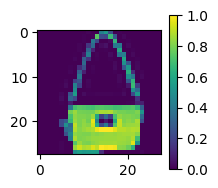

In [30]:
import torchvision.transforms as transforms

images, _ = next(iter(loaders['test']))
i = torch.randint(len(images), size=(1,)).item()
img = images[i]

plt.figure(figsize=(2, 2))
plt.imshow(img.squeeze())
plt.colorbar()
plt.show()

In [31]:
predictions = learner.model.predictions(img.to(device))
dict(sorted(predictions.items(), key=lambda item: item[1], reverse=True))

{'Bag': np.float32(0.9859569),
 'T-shirt/Top': np.float32(0.0060429093),
 'Dress': np.float32(0.00520719),
 'Sandal': np.float32(0.0011126293),
 'Pullover': np.float32(0.0007366813),
 'Coat': np.float32(0.0007079262),
 'Shirt': np.float32(0.00022886698),
 'Ankle-Boot': np.float32(3.5931048e-06),
 'Sneaker': np.float32(2.4266205e-06),
 'Trouser/Jeans': np.float32(7.825936e-07)}

In [32]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose(
    [
        transforms.Resize((28, 28)),
        transforms.Grayscale(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),  # Normalize
        transforms.Lambda(lambda x: 1.0 - x),  # Invert colors
        transforms.Lambda(lambda x: x[0]),
        transforms.Lambda(lambda x: x.unsqueeze(0)),
    ]
)

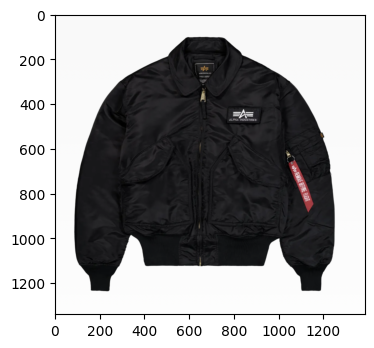

In [34]:
img = Image.open('images/jacket.png')
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.show()

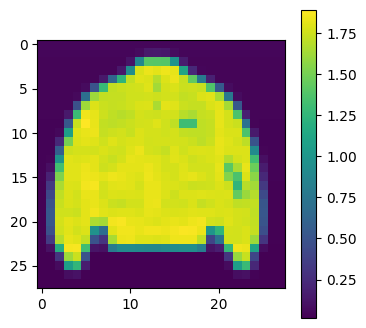

In [35]:
img = transform(img)
plt.figure(figsize=(4, 4))
plt.imshow(img.squeeze())
plt.colorbar()
plt.show()

In [37]:
predictions = learner.model.predictions(img.to(device))
dict(sorted(predictions.items(), key=lambda item: item[1], reverse=True))

{'Coat': np.float32(0.9785388),
 'Shirt': np.float32(0.016049236),
 'Pullover': np.float32(0.004903641),
 'Bag': np.float32(0.00050835125),
 'T-shirt/Top': np.float32(3.137565e-08),
 'Dress': np.float32(3.4691044e-10),
 'Trouser/Jeans': np.float32(3.4538533e-10),
 'Ankle-Boot': np.float32(3.3697266e-15),
 'Sandal': np.float32(2.9994843e-17),
 'Sneaker': np.float32(1.3033769e-19)}